# EE562 Final Project — Stereo SELD (DCASE 2025 Task 3)


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/DCASE2025_SELD_dataset', exist_ok=True)
!unzip -q /content/drive/MyDrive/EE562/features.zip -d /content/DCASE2025_SELD_dataset/
!unzip -q /content/drive/MyDrive/EE562/metadata_dev.zip -d /content/DCASE2025_SELD_dataset/
print('Data ready.')

Data ready.


In [3]:
!git clone https://github.com/mattwilk25/DCASE_2025_SELD.git
!pip install -q librosa scipy tqdm tensorboard

Cloning into 'DCASE_2025_SELD'...
remote: Enumerating objects: 292, done.
remote: Counting objects: 100% (292/292), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 292 (delta 165), reused 292 (delta 165), pack-reused 0 (from 0)
Receiving objects: 100% (292/292), 32.68 MiB | 16.04 MiB/s, done.
Resolving deltas: 100% (165/165), done.


In [4]:
# Fix dataset paths so the code finds the data in /content/
!sed -i "s|'../DCASE2025_SELD_dataset'|'/content/DCASE2025_SELD_dataset'|g" DCASE_2025_SELD/parameters.py
!sed -i "s|'audio_visual'|'audio'|g"                                         DCASE_2025_SELD/parameters.py
!sed -i "s|\['fold1', 'fold3'\]|\['fold3'\]|g"                               DCASE_2025_SELD/parameters.py
print('Parameters updated.')
%cd DCASE_2025_SELD

Parameters updated.
/content/DCASE_2025_SELD


## 2. Baseline Training (CRNN)

In [5]:
!python main.py 2>&1 | tee /content/drive/MyDrive/EE562/baseline_train_log.txt

2026-03-08 18:46:52.105980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 18:46:52.124506: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772995612.147488    1334 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772995612.155152    1334 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772995612.174543    1334 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 3. Improved Model Training (ResNet-Conformer + ACS)
Changes over baseline:
- **ResNet encoder**
- **Conformer layers**
- **Audio Channel Swapping (ACS)** (lets us get more data for transformer training)


In [6]:
!python main_improved.py 2>&1 | tee /content/drive/MyDrive/EE562/improved_train_log.txt

2026-03-08 22:34:10.702064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 22:34:10.720402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773009250.742755   58254 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773009250.750163   58254 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773009250.768928   58254 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 4. Results Comparison

In [5]:
import glob, re

def parse_log(log_path):
    """Extract epoch-wise F-score and loss from a training log file."""
    epochs, f_scores, train_losses = [], [], []
    with open(log_path) as f:
        for line in f:
            m = re.search(r'Epoch (\d+)/\d+.*Train Loss: ([\d.]+).*F-score: ([\d.]+)', line)
            if m:
                epochs.append(int(m.group(1)))
                train_losses.append(float(m.group(2)))
                f_scores.append(float(m.group(3)))
            else:
                m2 = re.search(r'Epoch (\d+)/\d+.*Train Loss: ([\d.]+)', line)
                if m2:
                    epochs.append(int(m2.group(1)))
                    train_losses.append(float(m2.group(2)))
                    f_scores.append(None)  # no val this epoch
    return epochs, train_losses, f_scores

baseline_log  = '/content/drive/MyDrive/EE562/baseline_train_log.txt'
improved_log  = '/content/drive/MyDrive/EE562/improved_train_log.txt'

b_epochs, b_losses, b_fscores = parse_log(baseline_log)
i_epochs, i_losses, i_fscores = parse_log(improved_log)
print(f'Baseline:  {len(b_epochs)} epochs parsed')
print(f'Improved:  {len(i_epochs)} epochs parsed')

Baseline:  200 epochs parsed
Improved:  200 epochs parsed


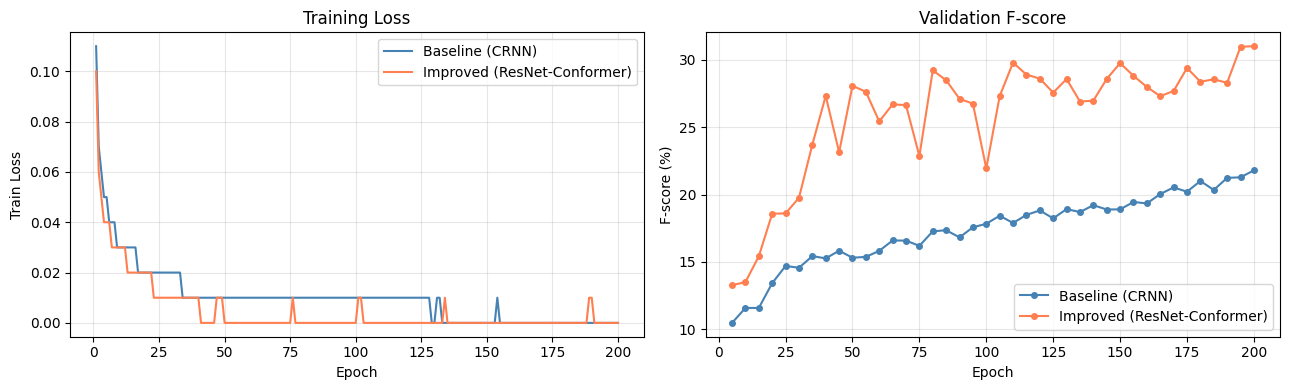

Baseline  best F-score: 21.80%
Improved  best F-score: 31.02%


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def val_points(epochs, fscores):
    """Return only epochs where validation was run."""
    e = [ep for ep, f in zip(epochs, fscores) if f is not None]
    f = [fs for fs in fscores if fs is not None]
    return e, f

b_val_e, b_val_f = val_points(b_epochs, b_fscores)
i_val_e, i_val_f = val_points(i_epochs, i_fscores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Training loss
ax1.plot(b_epochs, b_losses, label='Baseline (CRNN)',           color='steelblue')
ax1.plot(i_epochs, i_losses, label='Improved (ResNet-Conformer)', color='coral')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# F-score (validation epochs only)
ax2.plot(b_val_e, b_val_f, 'o-', label='Baseline (CRNN)',            color='steelblue', markersize=4)
ax2.plot(i_val_e, i_val_f, 'o-', label='Improved (ResNet-Conformer)', color='coral',     markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F-score (%)')
ax2.set_title('Validation F-score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EE562/training_curves.png', dpi=150)
plt.show()

if b_val_f:
    print(f'Baseline  best F-score: {max(b_val_f):.2f}%')
if i_val_f:
    print(f'Improved  best F-score: {max(i_val_f):.2f}%')

## 5. Prediction Visualization

In [18]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

GT_DIR     = '/content/DCASE2025_SELD_dataset/metadata_dev'
NB_CLASSES = 13
CLASS_NAMES = [
    'Female speech', 'Male speech', 'Clapping', 'Telephone', 'Laughter',
    'Domestic sounds', 'Footsteps', 'Door', 'Music',
    'Musical instrument', 'Water tap', 'Bell', 'Knock'
]
COLORS = plt.cm.tab20.colors

def read_csv(path):
    data = {}
    if not os.path.exists(path): return data
    with open(path) as f:
        lines = f.readlines()[1:]
    for line in lines:
        p = line.strip().split(',')
        if len(p) < 5: continue
        frame = int(p[0]); cls = int(p[1])
        az = float(p[3]); dist = float(p[4]) / 100.0
        data.setdefault(frame, []).append([cls, az, dist])
    return data

def data_to_arrays(data, nb_frames=50):
    active = np.zeros((nb_frames, NB_CLASSES), dtype=bool)
    az     = np.full((nb_frames, NB_CLASSES), np.nan)
    for frame, events in data.items():
        if frame >= nb_frames: continue
        for cls, a, _ in events:
            active[frame, cls] = True
            az[frame, cls] = a
    return active, az

# Build GT filename lookup once
gt_lookup = {os.path.basename(p): p
             for p in glob.glob(os.path.join(GT_DIR, '**', '*.csv'), recursive=True)}

# Find prediction directories for baseline and improved model
# Check within the current directory's outputs first, then in MyDrive
current_dir_output_pattern = 'outputs/SELDnet_audio_multiACCDOA_*/dev-test'
mydrive_output_pattern = '/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_*/dev-test'

all_out_dirs = sorted(glob.glob(current_dir_output_pattern))
print(f"DEBUG: all_out_dirs from current_dir_output_pattern: {all_out_dirs}")
if not all_out_dirs: # If not found in current directory, try MyDrive
    all_out_dirs = sorted(glob.glob(mydrive_output_pattern))
    print(f"DEBUG: all_out_dirs from mydrive_output_pattern: {all_out_dirs}")

# Based on the timestamps, the first directory is likely baseline and the second is improved
baseline_dirs = []
improved_dirs = []

if len(all_out_dirs) >= 1:
    # Assuming the first directory corresponds to the earlier run (baseline)
    baseline_dirs.append(all_out_dirs[0])
if len(all_out_dirs) >= 2:
    # Assuming the second directory corresponds to the later run (improved)
    improved_dirs.append(all_out_dirs[1])

BASELINE_PRED_DIR = baseline_dirs[0] if baseline_dirs else None
IMPROVED_PRED_DIR = improved_dirs[0] if improved_dirs else None

print('Baseline predictions:', BASELINE_PRED_DIR)
print('Improved predictions:', IMPROVED_PRED_DIR)


DEBUG: all_out_dirs from current_dir_output_pattern: []
DEBUG: all_out_dirs from mydrive_output_pattern: ['/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_184703/dev-test', '/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_223418/dev-test']
Baseline predictions: /content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_184703/dev-test
Improved predictions: /content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_223418/dev-test


### 5a. Class-wise Activity: GT vs Both Models

In [19]:
def count_activity(pred_dir):
    counts = np.zeros(NB_CLASSES)
    for pf in glob.glob(os.path.join(pred_dir, '*.csv')):
        for events in read_csv(pf).values():
            for cls, _, _ in events:
                counts[cls] += 1
    return counts

def count_gt_activity(pred_dir):
    counts = np.zeros(NB_CLASSES)
    for pf in glob.glob(os.path.join(pred_dir, '*.csv')):
        gf = gt_lookup.get(os.path.basename(pf))
        if gf:
            for events in read_csv(gf).values():
                for cls, _, _ in events:
                    counts[cls] += 1
    return counts

x = np.arange(NB_CLASSES)
w = 0.25

gt_counts       = count_gt_activity(BASELINE_PRED_DIR) if BASELINE_PRED_DIR else np.zeros(NB_CLASSES)
baseline_counts = count_activity(BASELINE_PRED_DIR)    if BASELINE_PRED_DIR else np.zeros(NB_CLASSES)
improved_counts = count_activity(IMPROVED_PRED_DIR)    if IMPROVED_PRED_DIR else np.zeros(NB_CLASSES)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w,   gt_counts,       w, label='Ground Truth',           color='dimgray',   alpha=0.85)
ax.bar(x,       baseline_counts, w, label='Baseline (CRNN)',         color='steelblue', alpha=0.85)
ax.bar(x + w,   improved_counts, w, label='Improved (ResNet-Conf.)', color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Active frame count')
ax.set_title('Class-wise Activity: Ground Truth vs Baseline vs Improved')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EE562/activity_comparison.png', dpi=150)
plt.show()

KeyboardInterrupt: 

In [15]:
import os
import glob

# List the contents of the 'outputs' directory to inspect the generated prediction folders
print('Contents of the expected outputs directory in MyDrive:')
!ls -l /content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs

# Also try to find the actual prediction directories with glob.glob to debug the pattern
# This time, focusing on the MyDrive path as indicated by the user.
all_found_dirs = sorted(glob.glob('/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/*/dev-test'))
print('\nDirectories found by glob.glob("/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/*/dev-test") before filtering:')
for d in all_found_dirs:
    print(d)


Contents of the expected outputs directory in MyDrive:
total 8
drwx------ 2 root root 4096 Mar  9 02:54 SELDnet_audio_multiACCDOA_20260308_184703
drwx------ 2 root root 4096 Mar  8 22:36 SELDnet_audio_multiACCDOA_20260308_223418

Directories found by glob.glob("/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/*/dev-test") before filtering:
/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_184703/dev-test
/content/drive/MyDrive/EE562/DCASE_2025_SELD/outputs/SELDnet_audio_multiACCDOA_20260308_223418/dev-test


### 5b. Azimuth Error per Class: Baseline vs Improved

In [20]:
def compute_az_errors(pred_dir):
    errors = {c: [] for c in range(NB_CLASSES)}
    for pf in glob.glob(os.path.join(pred_dir, '*.csv')):
        gf = gt_lookup.get(os.path.basename(pf))
        if not gf: continue
        pred = read_csv(pf); gt = read_csv(gf)
        for frame in set(pred) & set(gt):
            gm = {e[0]: e[1] for e in gt[frame]}
            pm = {e[0]: e[1] for e in pred[frame]}
            for cls in set(gm) & set(pm):
                err = abs(gm[cls] - pm[cls])
                errors[cls].append(min(err, 360 - err))
    return errors

b_errors = compute_az_errors(BASELINE_PRED_DIR) if BASELINE_PRED_DIR else {c: [] for c in range(NB_CLASSES)}
i_errors = compute_az_errors(IMPROVED_PRED_DIR) if IMPROVED_PRED_DIR else {c: [] for c in range(NB_CLASSES)}

# Median azimuth error per class
b_med = [np.median(b_errors[c]) if b_errors[c] else 0 for c in range(NB_CLASSES)]
i_med = [np.median(i_errors[c]) if i_errors[c] else 0 for c in range(NB_CLASSES)]

x = np.arange(NB_CLASSES); w = 0.38
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, b_med, w, label='Baseline (CRNN)',         color='steelblue', alpha=0.85)
ax.bar(x + w/2, i_med, w, label='Improved (ResNet-Conf.)', color='coral',     alpha=0.85)
ax.axhline(20, color='red', linestyle='--', linewidth=1, label='20° threshold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Median azimuth error (°)')
ax.set_title('Azimuth Error per Class: Baseline vs Improved (matched frames)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EE562/az_error_comparison.png', dpi=150)
plt.show()

KeyboardInterrupt: 

### 5c. Example Clip: Baseline vs Improved vs Ground Truth

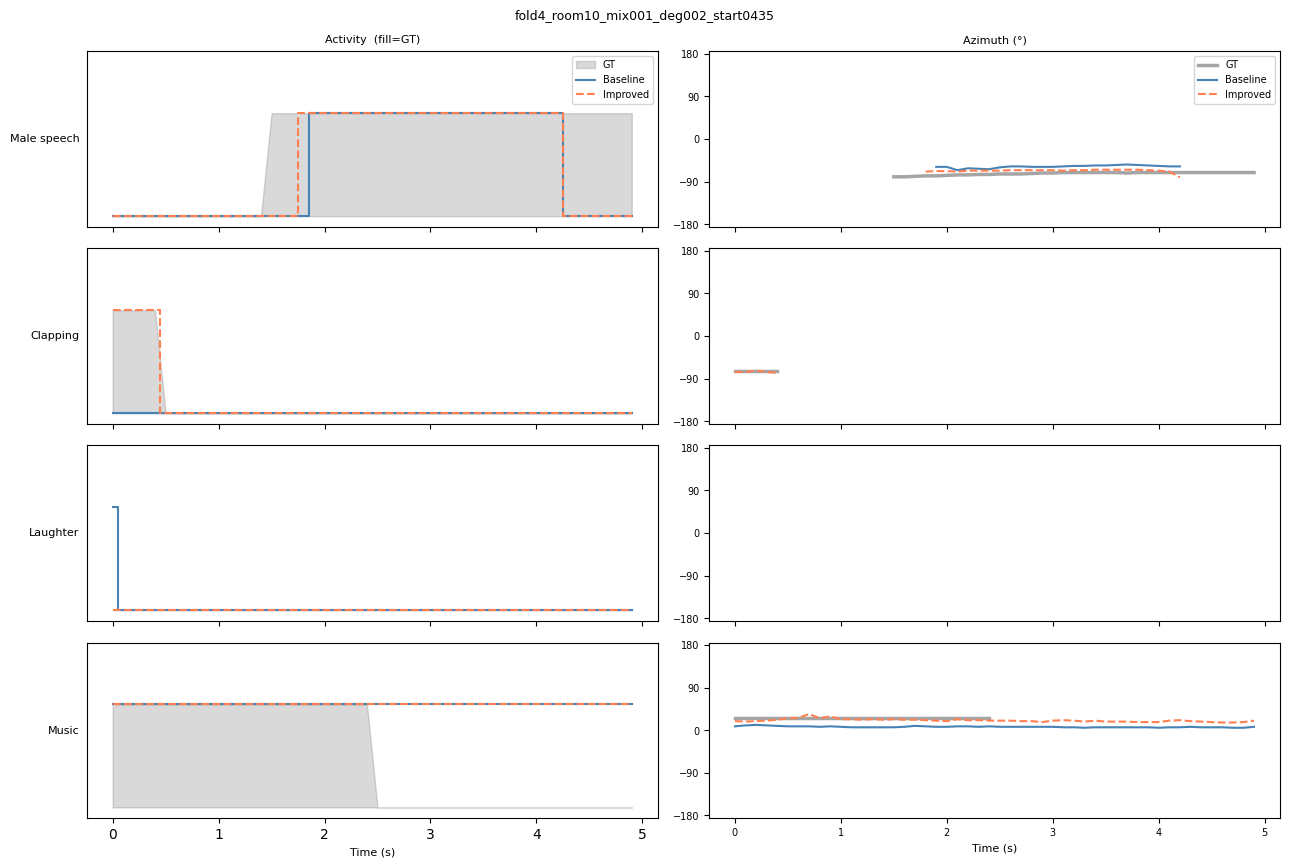

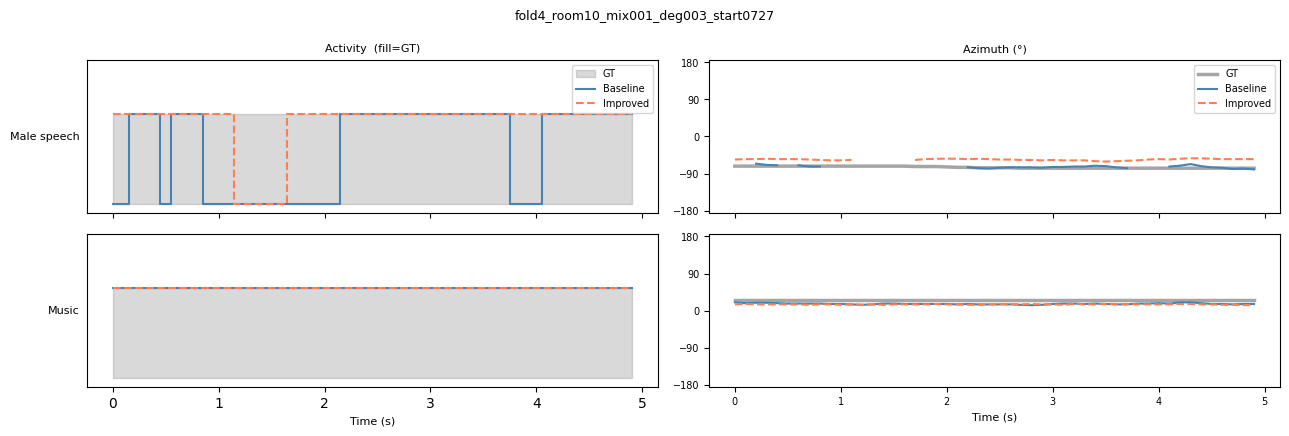

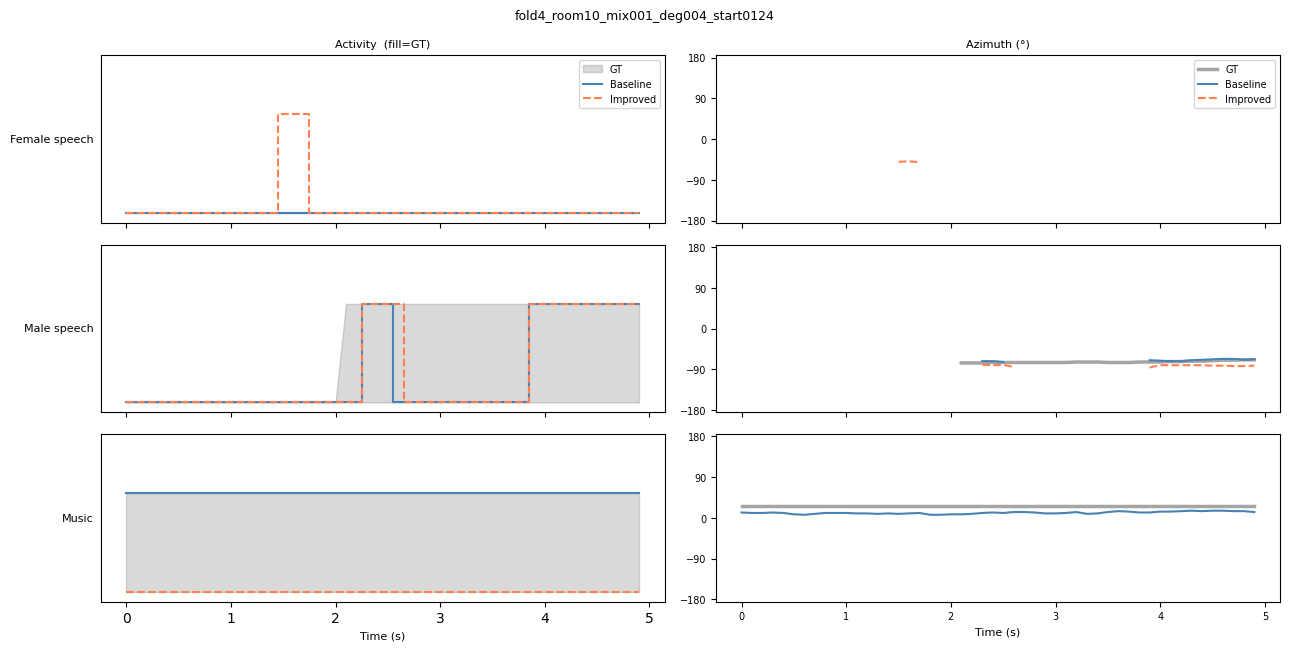

In [21]:
NB_EXAMPLES = 3

# Find clips with ground truth activity present in both prediction sets
b_files = {os.path.basename(p): p for p in glob.glob(os.path.join(BASELINE_PRED_DIR, '*.csv'))}
i_files = {os.path.basename(p): p for p in glob.glob(os.path.join(IMPROVED_PRED_DIR, '*.csv'))}
common  = sorted(set(b_files) & set(i_files) & set(gt_lookup))

examples = []
for fname in common:
    gf = gt_lookup[fname]
    if os.path.getsize(gf) > 100:
        examples.append(fname)
    if len(examples) >= NB_EXAMPLES:
        break

for fname in examples:
    gt   = read_csv(gt_lookup[fname])
    base = read_csv(b_files[fname])
    impr = read_csv(i_files[fname])

    nb_frames = 50
    time_axis = np.arange(nb_frames) * 0.1

    gt_act,   gt_az   = data_to_arrays(gt,   nb_frames)
    base_act, base_az = data_to_arrays(base, nb_frames)
    impr_act, impr_az = data_to_arrays(impr, nb_frames)

    active_cls = np.where(gt_act.any(0) | base_act.any(0) | impr_act.any(0))[0]
    if len(active_cls) == 0:
        continue

    fig, axes = plt.subplots(len(active_cls), 2,
                              figsize=(13, 2.2 * len(active_cls)), sharex=True)
    if len(active_cls) == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(fname.replace('.csv', ''), fontsize=9)

    for row, cls in enumerate(active_cls):
        color = COLORS[cls % len(COLORS)]

        # Activity
        ax_a = axes[row, 0]
        ax_a.fill_between(time_axis, 0, gt_act[:, cls].astype(float),
                          alpha=0.25, color='dimgray', label='GT')
        ax_a.step(time_axis, base_act[:, cls].astype(float),
                  where='mid', color='steelblue', linewidth=1.5, label='Baseline')
        ax_a.step(time_axis, impr_act[:, cls].astype(float),
                  where='mid', color='coral', linewidth=1.5, linestyle='--', label='Improved')
        ax_a.set_ylim(-0.1, 1.6)
        ax_a.set_yticks([])
        ax_a.set_ylabel(CLASS_NAMES[cls], fontsize=8, rotation=0, ha='right', va='center', labelpad=5)
        if row == 0:
            ax_a.set_title('Activity  (fill=GT)', fontsize=8)
            ax_a.legend(fontsize=7, loc='upper right')

        # Azimuth
        ax_z = axes[row, 1]
        ax_z.plot(time_axis, np.where(gt_act[:, cls],   gt_az[:, cls],   np.nan),
                  color='dimgray',   alpha=0.6, linewidth=2.5, linestyle='-',  label='GT')
        ax_z.plot(time_axis, np.where(base_act[:, cls], base_az[:, cls], np.nan),
                  color='steelblue', linewidth=1.5,             label='Baseline')
        ax_z.plot(time_axis, np.where(impr_act[:, cls], impr_az[:, cls], np.nan),
                  color='coral',     linewidth=1.5, linestyle='--', label='Improved')
        ax_z.set_ylim(-185, 185)
        ax_z.set_yticks([-180, -90, 0, 90, 180])
        ax_z.tick_params(labelsize=7)
        if row == 0:
            ax_z.set_title('Azimuth (°)', fontsize=8)
            ax_z.legend(fontsize=7, loc='upper right')

    axes[-1, 0].set_xlabel('Time (s)', fontsize=8)
    axes[-1, 1].set_xlabel('Time (s)', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/EE562/clip_{fname.replace(".csv","")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()